# Stockout / Backorder Prediction — Data Preparation

## Objective

Prepare the Product Backorder dataset for stockout-risk prediction in the Nivera
Retail Enterprise Inventory Intelligence platform.

The notebook covers:

1. Dataset loading
2. Dataset inspection
3. Missing-value analysis
4. Data cleaning
5. Exploratory Data Analysis
6. Feature engineering
7. Train-validation split
8. Preprocessing
9. Saving processed data and preprocessing artifacts

The target variable is `went_on_backorder`.

In [10]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [11]:
TRAIN_PATH = "../data/raw/Training_BOP.csv"
TEST_PATH = "../data/raw/Testing_BOP.csv"

PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
OUTPUT_DIR = "../outputs"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Directories ready.")

Directories ready.


In [12]:
df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

# Treat SKU purely as an identifier
df["sku"] = df["sku"].astype(str)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1687861, 23)


In [15]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Number of rows: 1687861
Number of columns: 23

Columns:
01. sku
02. national_inv
03. lead_time
04. in_transit_qty
05. forecast_3_month
06. forecast_6_month
07. forecast_9_month
08. sales_1_month
09. sales_3_month
10. sales_6_month
11. sales_9_month
12. min_bank
13. potential_issue
14. pieces_past_due
15. perf_6_month_avg
16. perf_12_month_avg
17. local_bo_qty
18. deck_risk
19. oe_constraint
20. ppap_risk
21. stop_auto_buy
22. rev_stop
23. went_on_backorder


In [16]:
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
    })
)

,Column,Data Type,Unique Values
0,sku,object,1687861
1,national_inv,float64,14970
2,lead_time,float64,33
3,in_transit_qty,float64,5231
4,forecast_3_month,float64,7826
5,forecast_6_month,float64,11115
6,forecast_9_month,float64,13663
7,sales_1_month,float64,5765
8,sales_3_month,float64,10496
9,sales_6_month,float64,14819


In [19]:
target_counts = df["went_on_backorder"].value_counts(dropna=False)

print(target_counts)

print("\nTarget percentages:")
print(
    (target_counts / len(df) * 100).round(4)
)

went_on_backorder
No     1676567
Yes      11293
NaN          1
Name: count, dtype: int64

Target percentages:
went_on_backorder
No     99.3309
Yes     0.6691
NaN     0.0001
Name: count, dtype: float64


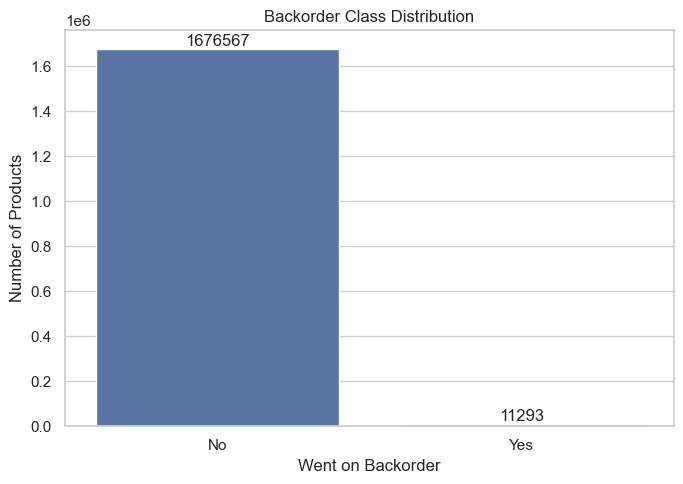

In [18]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="went_on_backorder",
    order=df["went_on_backorder"].value_counts().index
)

plt.title("Backorder Class Distribution")
plt.xlabel("Went on Backorder")
plt.ylabel("Number of Products")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

In [20]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [21]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(4)
})

missing_df = missing_df[
    missing_df["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

display(missing_df)

,Missing Count,Missing Percentage
lead_time,100894,5.9776
national_inv,1,0.0001
in_transit_qty,1,0.0001
forecast_3_month,1,0.0001
forecast_6_month,1,0.0001
forecast_9_month,1,0.0001
sales_1_month,1,0.0001
sales_3_month,1,0.0001
sales_6_month,1,0.0001
sales_9_month,1,0.0001


In [22]:
print(
    "Missing target values before:",
    df["went_on_backorder"].isna().sum()
)

df = df.dropna(
    subset=["went_on_backorder"]
).copy()

print(
    "Missing target values after:",
    df["went_on_backorder"].isna().sum()
)

print("New shape:", df.shape)

Missing target values before: 1
Missing target values after: 0
New shape: (1687860, 23)


In [23]:
performance_columns = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

for col in performance_columns:
    print(f"\n{col}")
    print("Number of -99 values:", (df[col] == -99).sum())
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


perf_6_month_avg
Number of -99 values: 129478
Minimum: -99.0
Maximum: 1.0

perf_12_month_avg
Number of -99 values: 122050
Minimum: -99.0
Maximum: 1.0


In [24]:
for col in performance_columns:
    df[col] = df[col].replace(-99, np.nan)

print("Special -99 values converted to NaN.")

Special -99 values converted to NaN.


In [25]:
categorical_columns = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False))


potential_issue
potential_issue
No     1686953
Yes        907
Name: count, dtype: int64

deck_risk
deck_risk
No     1300377
Yes     387483
Name: count, dtype: int64

oe_constraint
oe_constraint
No     1687615
Yes        245
Name: count, dtype: int64

ppap_risk
ppap_risk
No     1484026
Yes     203834
Name: count, dtype: int64

stop_auto_buy
stop_auto_buy
Yes    1626774
No       61086
Name: count, dtype: int64

rev_stop
rev_stop
No     1687129
Yes        731
Name: count, dtype: int64


In [26]:
numerical_columns = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty"
]

display(
    df[numerical_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
national_inv,1687860.0,496.111782,29615.233831,-27256.0,4.00,15.00,80.00,12334404.0
lead_time,1586967.0,7.872267,7.056024,0.0,4.00,8.00,9.00,52.0
in_transit_qty,1687860.0,44.052022,1342.741731,0.0,0.00,0.00,0.00,489408.0
forecast_3_month,1687860.0,178.119284,5026.553102,0.0,0.00,0.00,4.00,1427612.0
forecast_6_month,1687860.0,344.986664,9795.151861,0.0,0.00,0.00,12.00,2461360.0
forecast_9_month,1687860.0,506.364431,14378.923562,0.0,0.00,0.00,20.00,3777304.0
sales_1_month,1687860.0,55.926069,1928.195879,0.0,0.00,0.00,4.00,741774.0
sales_3_month,1687860.0,175.025930,5192.377625,0.0,0.00,1.00,15.00,1105478.0
sales_6_month,1687860.0,341.728839,9613.167104,0.0,0.00,2.00,31.00,2146625.0
sales_9_month,1687860.0,525.269701,14838.613523,0.0,0.00,4.00,47.00,3205172.0


In [27]:
negative_inventory = (df["national_inv"] < 0).sum()

print("Products with negative national inventory:", negative_inventory)
print(
    "Percentage:",
    round(negative_inventory / len(df) * 100, 4),
    "%"
)

Products with negative national inventory: 5888
Percentage: 0.3488 %


In [28]:
# Avoid division by zero
EPSILON = 1e-6

# Average monthly sales based on 3-month history
df["avg_monthly_sales_3m"] = df["sales_3_month"] / 3

# Average monthly sales based on 6-month history
df["avg_monthly_sales_6m"] = df["sales_6_month"] / 6

# Average monthly sales based on 9-month history
df["avg_monthly_sales_9m"] = df["sales_9_month"] / 9

# Inventory relative to forecast demand
df["inventory_to_forecast"] = (
    df["national_inv"] /
    (df["forecast_3_month"].abs() + EPSILON)
)

# Forecast relative to recent sales
df["forecast_vs_sales"] = (
    df["forecast_3_month"] /
    (df["avg_monthly_sales_3m"] + EPSILON)
)

# Inventory gap
df["inventory_gap"] = (
    df["national_inv"] - df["forecast_3_month"]
)

# Demand pressure
df["demand_pressure"] = (
    (df["forecast_3_month"] - df["national_inv"]) /
    (df["forecast_3_month"].abs() + EPSILON)
)

# Inventory currently in transit relative to forecast
df["in_transit_ratio"] = (
    df["in_transit_qty"] /
    (df["forecast_3_month"].abs() + EPSILON)
)

# Recent sales acceleration
df["sales_acceleration"] = (
    df["sales_1_month"] /
    (df["avg_monthly_sales_3m"] + EPSILON)
)

# Forecast horizon growth
df["forecast_growth_6m"] = (
    df["forecast_6_month"] /
    (df["forecast_3_month"].abs() + EPSILON)
)

df["forecast_growth_9m"] = (
    df["forecast_9_month"] /
    (df["forecast_3_month"].abs() + EPSILON)
)

# Estimated demand during lead time
df["lead_time_demand"] = (
    df["avg_monthly_sales_3m"] *
    df["lead_time"] / 30
)

# Inventory coverage ratio
df["inventory_coverage"] = (
    df["national_inv"] /
    (df["avg_monthly_sales_3m"] + EPSILON)
)

print("Feature engineering completed.")
print("New shape:", df.shape)

Feature engineering completed.
New shape: (1687860, 36)


In [29]:
engineered_features = [
    "avg_monthly_sales_3m",
    "avg_monthly_sales_6m",
    "avg_monthly_sales_9m",
    "inventory_to_forecast",
    "forecast_vs_sales",
    "inventory_gap",
    "demand_pressure",
    "in_transit_ratio",
    "sales_acceleration",
    "forecast_growth_6m",
    "forecast_growth_9m",
    "lead_time_demand",
    "inventory_coverage"
]

display(
    df[engineered_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
avg_monthly_sales_3m,1687860.0,5.834198e+01,1.730793e+03,0.000000e+00,0.000000e+00,3.333333e-01,5.000000e+00,3.684927e+05
avg_monthly_sales_6m,1687860.0,5.695481e+01,1.602195e+03,0.000000e+00,0.000000e+00,3.333333e-01,5.166667e+00,3.577708e+05
avg_monthly_sales_9m,1687860.0,5.836330e+01,1.648735e+03,0.000000e+00,0.000000e+00,4.444444e-01,5.222222e+00,3.561302e+05
inventory_to_forecast,1687860.0,3.667870e+08,2.946623e+10,-5.760000e+09,1.533333e+00,5.000000e+06,2.700000e+07,1.233440e+13
forecast_vs_sales,1687860.0,1.726190e+07,1.515150e+09,0.000000e+00,0.000000e+00,0.000000e+00,1.868852e+00,7.176080e+11
inventory_gap,1687860.0,3.179925e+02,2.964872e+04,-8.057110e+05,2.000000e+00,9.000000e+00,4.300000e+01,1.233440e+07
demand_pressure,1687860.0,-3.667870e+08,2.946623e+10,-1.233440e+13,-2.700000e+07,-5.000000e+06,-5.333333e-01,5.760000e+09
in_transit_ratio,1687860.0,5.196433e+06,5.106780e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.853650e+11
sales_acceleration,1687860.0,5.117744e-01,7.446034e-01,0.000000e+00,0.000000e+00,0.000000e+00,9.272727e-01,3.000000e+00
forecast_growth_6m,1687860.0,8.212849e+06,3.690721e+08,0.000000e+00,0.000000e+00,0.000000e+00,1.545454e+00,1.044000e+11


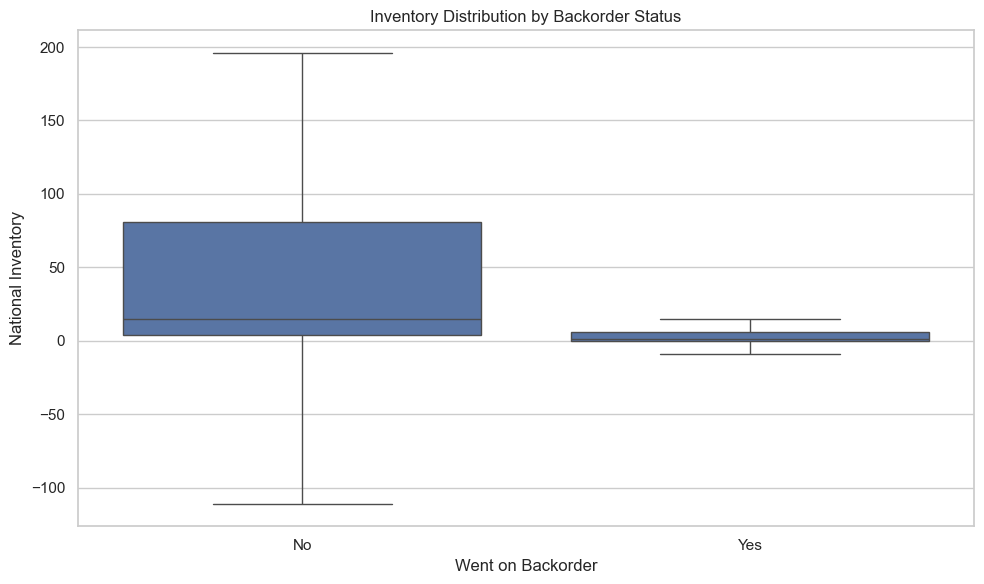

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="went_on_backorder",
    y="national_inv",
    showfliers=False
)

plt.title("Inventory Distribution by Backorder Status")
plt.xlabel("Went on Backorder")
plt.ylabel("National Inventory")

plt.tight_layout()
plt.show()

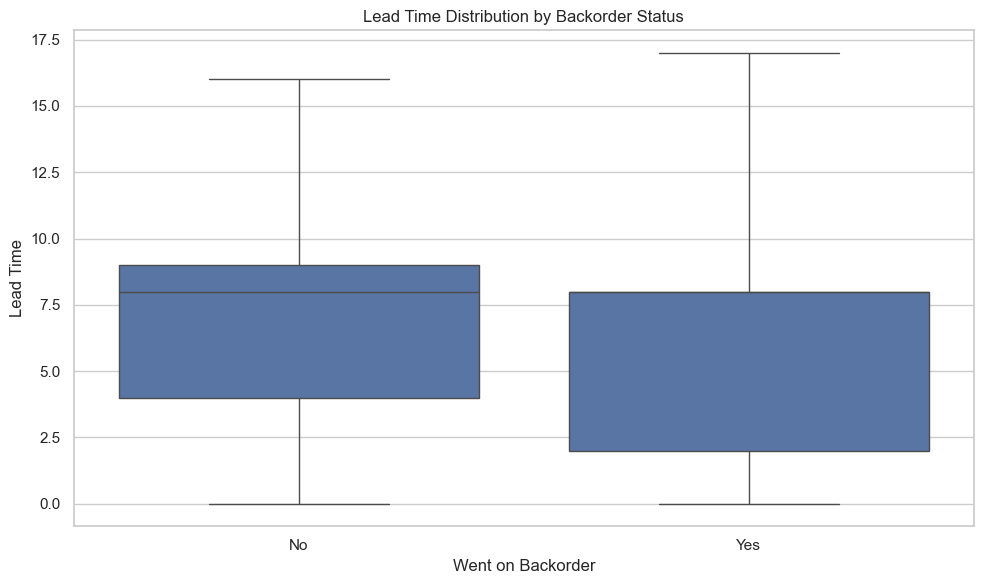

In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="went_on_backorder",
    y="lead_time",
    showfliers=False
)

plt.title("Lead Time Distribution by Backorder Status")
plt.xlabel("Went on Backorder")
plt.ylabel("Lead Time")

plt.tight_layout()
plt.show()

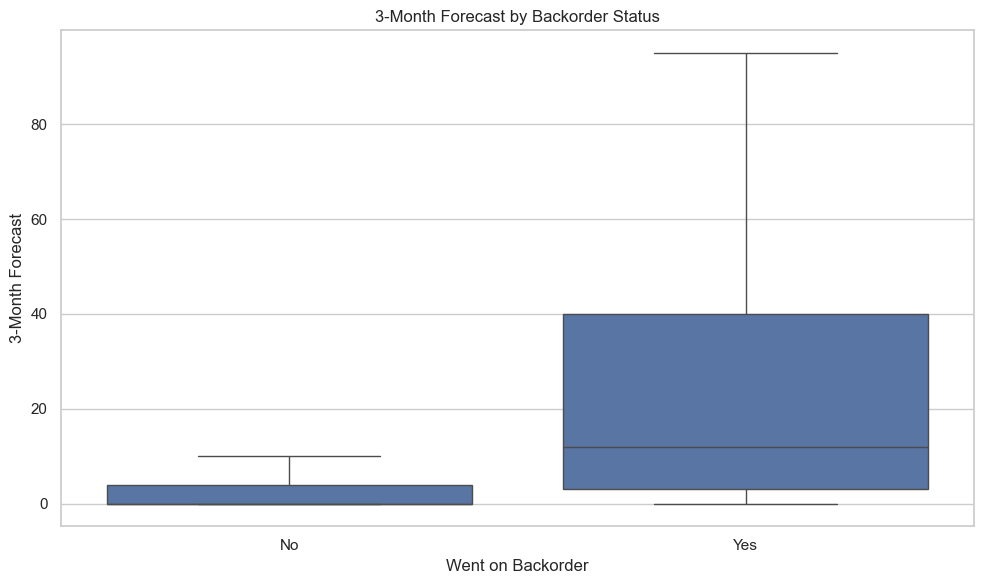

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="went_on_backorder",
    y="forecast_3_month",
    showfliers=False
)

plt.title("3-Month Forecast by Backorder Status")
plt.xlabel("Went on Backorder")
plt.ylabel("3-Month Forecast")

plt.tight_layout()
plt.show()

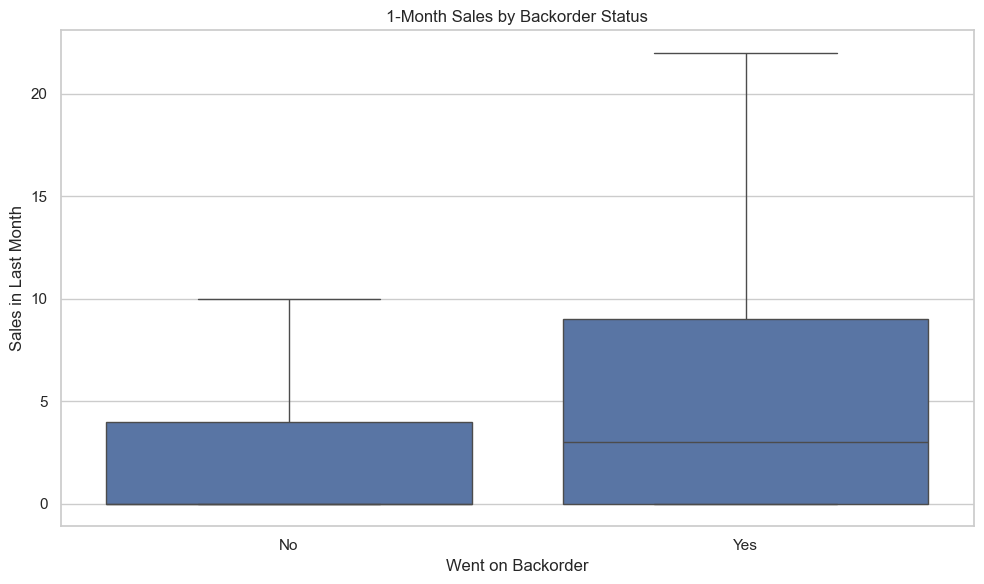

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="went_on_backorder",
    y="sales_1_month",
    showfliers=False
)

plt.title("1-Month Sales by Backorder Status")
plt.xlabel("Went on Backorder")
plt.ylabel("Sales in Last Month")

plt.tight_layout()
plt.show()

In [36]:
for col in categorical_columns:

    rate = (
        df.groupby(col, dropna=False)["went_on_backorder"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 60)
    print(f"Backorder Rate by {col}")
    display(rate.to_frame("Backorder Rate (%)"))


Backorder Rate by potential_issue


,Backorder Rate (%)
potential_issue,
Yes,5.622933
No,0.666409



Backorder Rate by deck_risk


,Backorder Rate (%)
deck_risk,
No,0.721099
Yes,0.494473



Backorder Rate by oe_constraint


...

,Backorder Rate (%)
ppap_risk,
Yes,0.862957
No,0.642442



Backorder Rate by stop_auto_buy


,Backorder Rate (%)
stop_auto_buy,
No,0.771044
Yes,0.665243



Backorder Rate by rev_stop


,Backorder Rate (%)
rev_stop,
No,0.669362
Yes,0.000000


In [38]:
df["target_numeric"] = (
    df["went_on_backorder"] == "Yes"
).astype(int)

correlation_features = numerical_columns + engineered_features + [
    "target_numeric"
]

correlation_matrix = df[
    correlation_features
].corr()

target_correlations = (
    correlation_matrix["target_numeric"]
    .drop("target_numeric")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    target_correlations.to_frame(
        "Correlation with Backorder"
    )
)

,Correlation with Backorder
sales_acceleration,0.047315
perf_6_month_avg,-0.028322
perf_12_month_avg,-0.027993
lead_time,-0.018323
local_bo_qty,0.009504
in_transit_qty,-0.002427
min_bank,-0.001867
sales_9_month,-0.001764
avg_monthly_sales_9m,-0.001764
sales_6_month,-0.001728


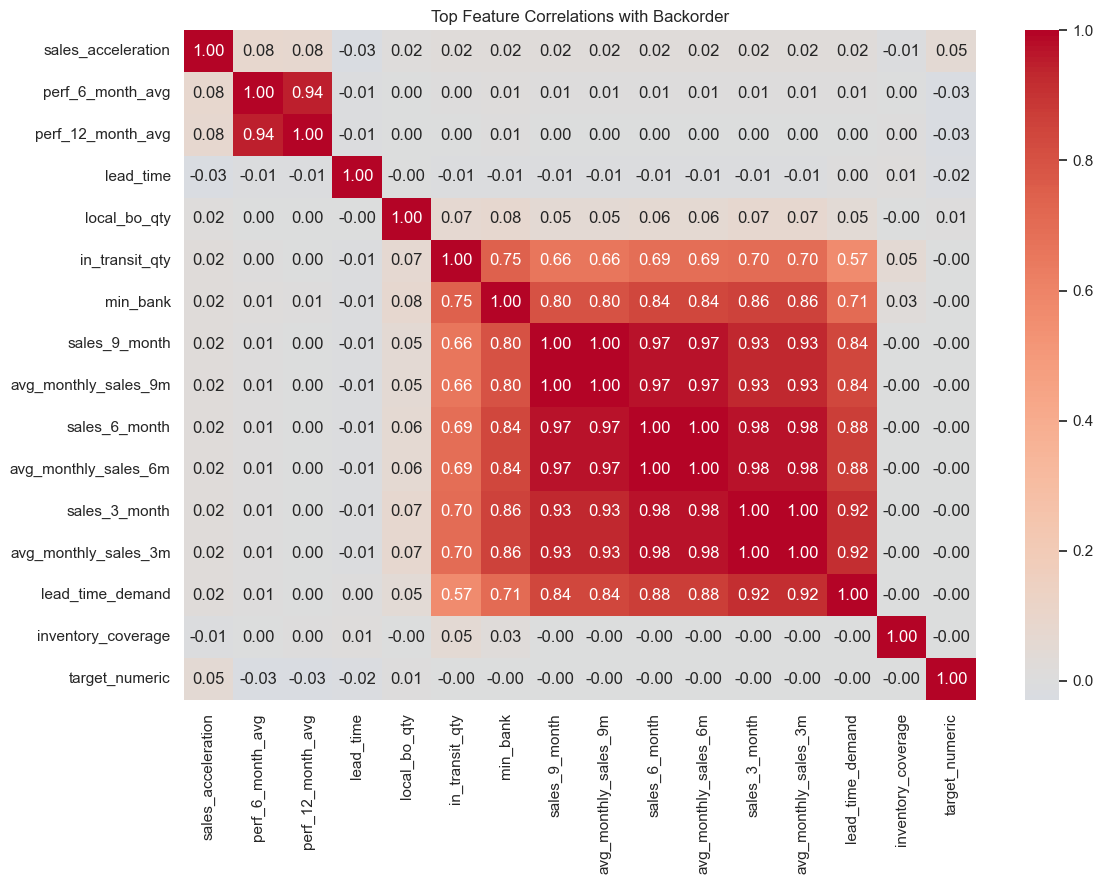

In [39]:
top_corr_features = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

heatmap_features = top_corr_features + ["target_numeric"]

plt.figure(figsize=(12, 9))

sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Top Feature Correlations with Backorder")
plt.tight_layout()
plt.show()

In [40]:
df.drop(
    columns=["target_numeric"],
    inplace=True
)

In [41]:
TARGET = "went_on_backorder"

DROP_COLUMNS = [
    "sku"
]

NUMERICAL_FEATURES = [
    "national_inv",
    "lead_time",
    "in_transit_qty",
    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",
    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",
    "min_bank",
    "pieces_past_due",
    "perf_6_month_avg",
    "perf_12_month_avg",
    "local_bo_qty",

    # Engineered features
    "avg_monthly_sales_3m",
    "avg_monthly_sales_6m",
    "avg_monthly_sales_9m",
    "inventory_to_forecast",
    "forecast_vs_sales",
    "inventory_gap",
    "demand_pressure",
    "in_transit_ratio",
    "sales_acceleration",
    "forecast_growth_6m",
    "forecast_growth_9m",
    "lead_time_demand",
    "inventory_coverage"
]

CATEGORICAL_FEATURES = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print("Number of numerical features:", len(NUMERICAL_FEATURES))
print("Number of categorical features:", len(CATEGORICAL_FEATURES))
print("Total model features before encoding:", len(FEATURES))

Number of numerical features: 28
Number of categorical features: 6
Total model features before encoding: 34


In [42]:
X = df[FEATURES].copy()

y = (
    df[TARGET]
    .map({
        "No": 0,
        "Yes": 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True).mul(100).round(4)
)

X shape: (1687860, 34)
y shape: (1687860,)

Target distribution:
went_on_backorder
0    1676567
1      11293
Name: count, dtype: int64

Target percentage:
went_on_backorder
0    99.3309
1     0.6691
Name: proportion, dtype: float64


In [43]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_valid.value_counts())

Training set: (1350288, 34)
Validation set: (337572, 34)

Training target distribution:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64

Validation target distribution:
went_on_backorder
0    335313
1      2259
Name: count, dtype: int64


In [44]:
print("Training backorder rate:")
print(round(y_train.mean() * 100, 4), "%")

print("\nValidation backorder rate:")
print(round(y_valid.mean() * 100, 4), "%")

Training backorder rate:
0.669 %

Validation backorder rate:
0.6692 %


In [45]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            NUMERICAL_FEATURES
        ),
        (
            "cat",
            categorical_transformer,
            CATEGORICAL_FEATURES
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [46]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

print("Training processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_valid_processed.shape)

Training processed shape: (1350288, 40)
Validation processed shape: (337572, 40)


In [47]:
print(
    "Processed training matrix type:",
    type(X_train_processed)
)

print(
    "Processed validation matrix type:",
    type(X_valid_processed)
)

print(
    "Training matrix memory-friendly sparse:",
    hasattr(X_train_processed, "tocsr")
)

Processed training matrix type: <class 'numpy.ndarray'>
Processed validation matrix type: <class 'numpy.ndarray'>
Training matrix memory-friendly sparse: False


In [48]:
PREPROCESSOR_PATH = os.path.join(
    MODEL_DIR,
    "stockout_preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

print(
    "Preprocessor saved to:",
    PREPROCESSOR_PATH
)

Preprocessor saved to: ../models\stockout_preprocessor.joblib


In [50]:
import numpy as np
import os

X_train_path = os.path.join(
    PROCESSED_DIR,
    "X_train.npy"
)

X_valid_path = os.path.join(
    PROCESSED_DIR,
    "X_valid.npy"
)

y_train_path = os.path.join(
    PROCESSED_DIR,
    "y_train.npy"
)

y_valid_path = os.path.join(
    PROCESSED_DIR,
    "y_valid.npy"
)

# Save processed feature matrices
np.save(
    X_train_path,
    X_train_processed
)

np.save(
    X_valid_path,
    X_valid_processed
)

# Save target arrays
np.save(
    y_train_path,
    y_train.to_numpy()
)

np.save(
    y_valid_path,
    y_valid.to_numpy()
)

print("Processed datasets saved successfully.")

print("\nFiles:")
print(X_train_path)
print(X_valid_path)
print(y_train_path)
print(y_valid_path)

Processed datasets saved successfully.

Files:
../data/processed\X_train.npy
../data/processed\X_valid.npy
../data/processed\y_train.npy
../data/processed\y_valid.npy


In [51]:
feature_info = {
    "target": TARGET,
    "drop_columns": DROP_COLUMNS,
    "numerical_features": NUMERICAL_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "all_features": FEATURES,
    "random_state": RANDOM_STATE
}

joblib.dump(
    feature_info,
    os.path.join(
        MODEL_DIR,
        "feature_info.joblib"
    )
)

print("Feature information saved.")

Feature information saved.


In [52]:
print("=" * 70)
print("FINAL DATA PREPARATION SUMMARY")
print("=" * 70)

print(f"Original rows:              1,687,861")
print(f"Rows after target cleaning: {len(df):,}")
print(f"Training rows:              {len(X_train):,}")
print(f"Validation rows:            {len(X_valid):,}")

print(
    f"\nBackorder rate:             {y.mean() * 100:.4f}%"
)

print(
    f"Training backorder rate:    {y_train.mean() * 100:.4f}%"
)

print(
    f"Validation backorder rate:  {y_valid.mean() * 100:.4f}%"
)

print(
    f"\nRaw model features:         {len(FEATURES)}"
)

print(
    f"Encoded features:           {X_train_processed.shape[1]}"
)

print("\nSaved files:")
print("✓ stockout_preprocessor.joblib")
print("✓ feature_info.joblib")
print("✓ X_train.npz")
print("✓ X_valid.npz")
print("✓ y_train.npy")
print("✓ y_valid.npy")

FINAL DATA PREPARATION SUMMARY
Original rows:              1,687,861
Rows after target cleaning: 1,687,860
Training rows:              1,350,288
Validation rows:            337,572

Backorder rate:             0.6691%
Training backorder rate:    0.6690%
Validation backorder rate:  0.6692%

Raw model features:         34
Encoded features:           40

Saved files:
✓ stockout_preprocessor.joblib
✓ feature_info.joblib
✓ X_train.npz
✓ X_valid.npz
✓ y_train.npy
✓ y_valid.npy


In [53]:
CLEAN_DATA_PATH = os.path.join(
    PROCESSED_DIR,
    "cleaned_backorder_data.csv"
)

df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print(
    "Cleaned dataset saved to:",
    CLEAN_DATA_PATH
)

Cleaned dataset saved to: ../data/processed\cleaned_backorder_data.csv
